In [ ]:

!pip install mplsoccer statsbombpy --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch, Sbopen, VerticalPitch
from statsbombpy import sb

plt.rcParams['figure.dpi'] = 120

In [ ]:
parser = Sbopen()
df, related, freeze, tactics = parser.event(69301)

In [ ]:
from statsbombpy import sb

target_match_id = 69301

# get all competitions
competitions = sb.competitions()

found = None

for _, row in competitions.iterrows():
    matches = sb.matches(
        competition_id=row['competition_id'],
        season_id=row['season_id']
    )

    match = matches[matches['match_id'] == target_match_id]
    if not match.empty:
        found = {
            'competition_name': row['competition_name'],
            'season_name': row['season_name'],
            'competition_id': row['competition_id'],
            'season_id': row['season_id']
        }
        break

found


{'competition_name': "Women's World Cup",
 'season_name': '2019',
 'competition_id': 72,
 'season_id': 30}

In [ ]:
# get team names
team1, team2 = df.team_name.unique()
team1, team2

("England Women's", "Sweden Women's")

In [ ]:
# dataframe of shots
shots = df.loc[df['type_name'] == 'Shot'].set_index('id')

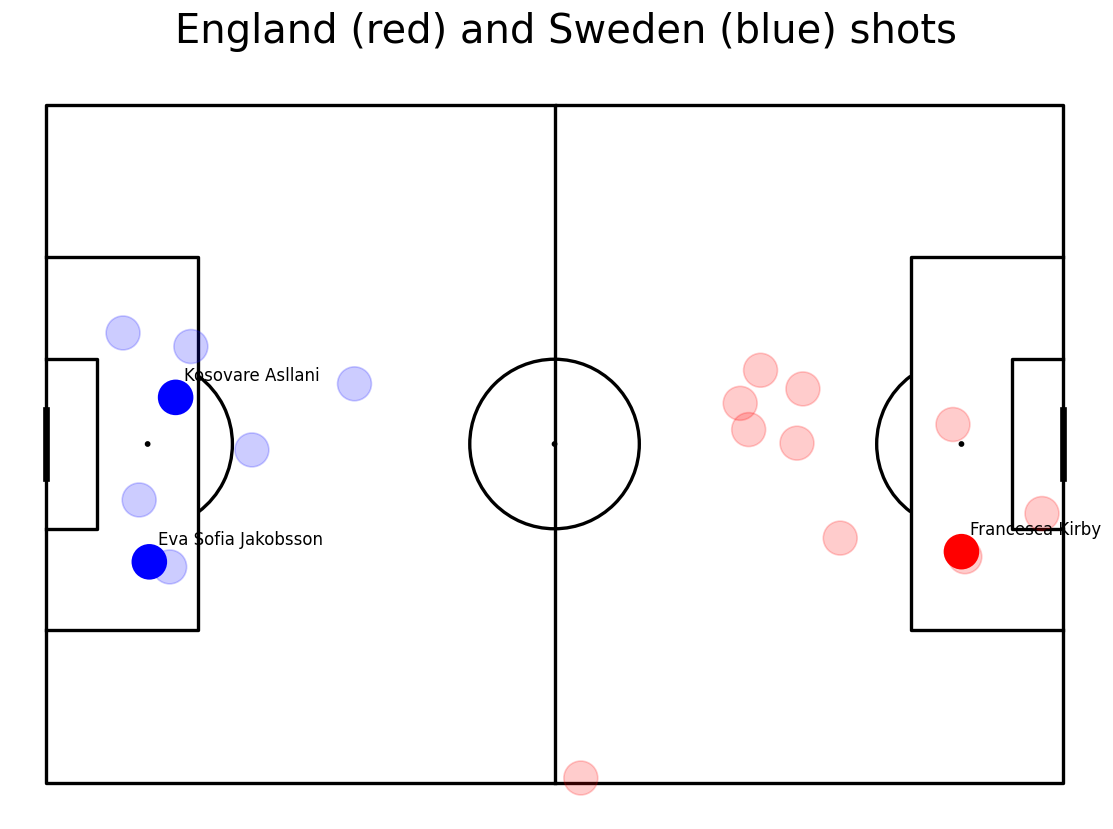

In [ ]:
pitch = Pitch(line_color="black")
fig, ax = pitch.draw(figsize=(10, 7))

# Size of the pitch in yards
pitchLengthX = 120
pitchWidthY = 80

for i, shot in shots.iterrows():
    x = shot['x']
    y = shot['y']
    goal = shot['outcome_name'] == 'Goal'
    team_name = shot['team_name']
    circleSize = 2

    # England
    if team_name == team1:
        if goal:
            shotCircle = plt.Circle((x, y), circleSize, color="red")
            plt.text(x + 1, y - 2, shot['player_name'])
        else:
            shotCircle = plt.Circle((x, y), circleSize, color="red", alpha=0.2)

    # Sweden
    else:
        if goal:
            shotCircle = plt.Circle((pitchLengthX - x, pitchWidthY - y), circleSize, color="blue")
            plt.text(pitchLengthX - x + 1, pitchWidthY - y - 2, shot['player_name'])
        else:
            shotCircle = plt.Circle((pitchLengthX - x, pitchWidthY - y), circleSize, color="blue", alpha=0.2)

    ax.add_patch(shotCircle)

fig.suptitle("England (red) and Sweden (blue) shots", fontsize=24)
plt.show()

Alternate way

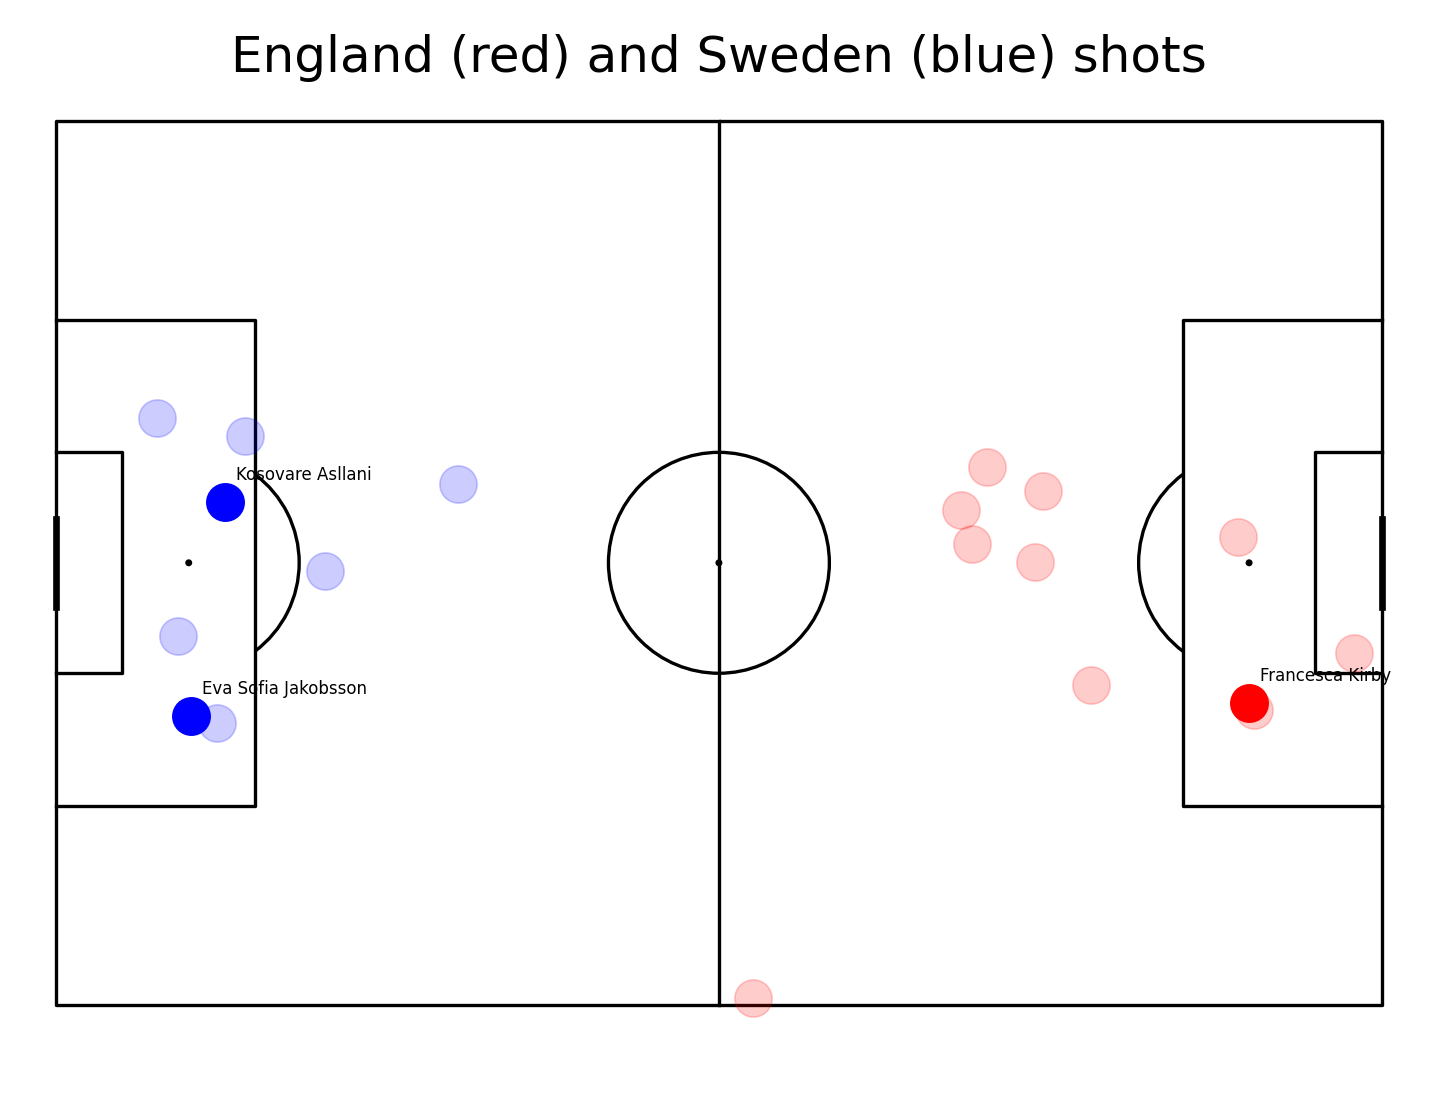

In [ ]:
pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)

mask_england = (df.type_name == 'Shot') & (df.team_name == team1)
df_england = df.loc[mask_england, ['x', 'y', 'outcome_name', 'player_name']]

for i, row in df_england.iterrows():
    if row['outcome_name'] == 'Goal':
        pitch.scatter(row.x, row.y, s=500, color='red', ax=ax['pitch'])
        pitch.annotate(row['player_name'], (row.x + 1, row.y - 2), ax=ax['pitch'])
    else:
        pitch.scatter(row.x, row.y, s=500, color='red', alpha=0.2, ax=ax['pitch'])

mask_sweden = (df.type_name == 'Shot') & (df.team_name == team2)
df_sweden = df.loc[mask_sweden, ['x', 'y', 'outcome_name', 'player_name']]

for i, row in df_sweden.iterrows():
    if row['outcome_name'] == 'Goal':
        pitch.scatter(120 - row.x, 80 - row.y, s=500, color='blue', ax=ax['pitch'])
        pitch.annotate(row['player_name'], (120 - row.x + 1, 80 - row.y - 2), ax=ax['pitch'])
    else:
        pitch.scatter(120 - row.x, 80 - row.y, s=500, color='blue', alpha=0.2, ax=ax['pitch'])

fig.suptitle("England (red) and Sweden (blue) shots", fontsize=30)
plt.show()

Plotting half of the pitch

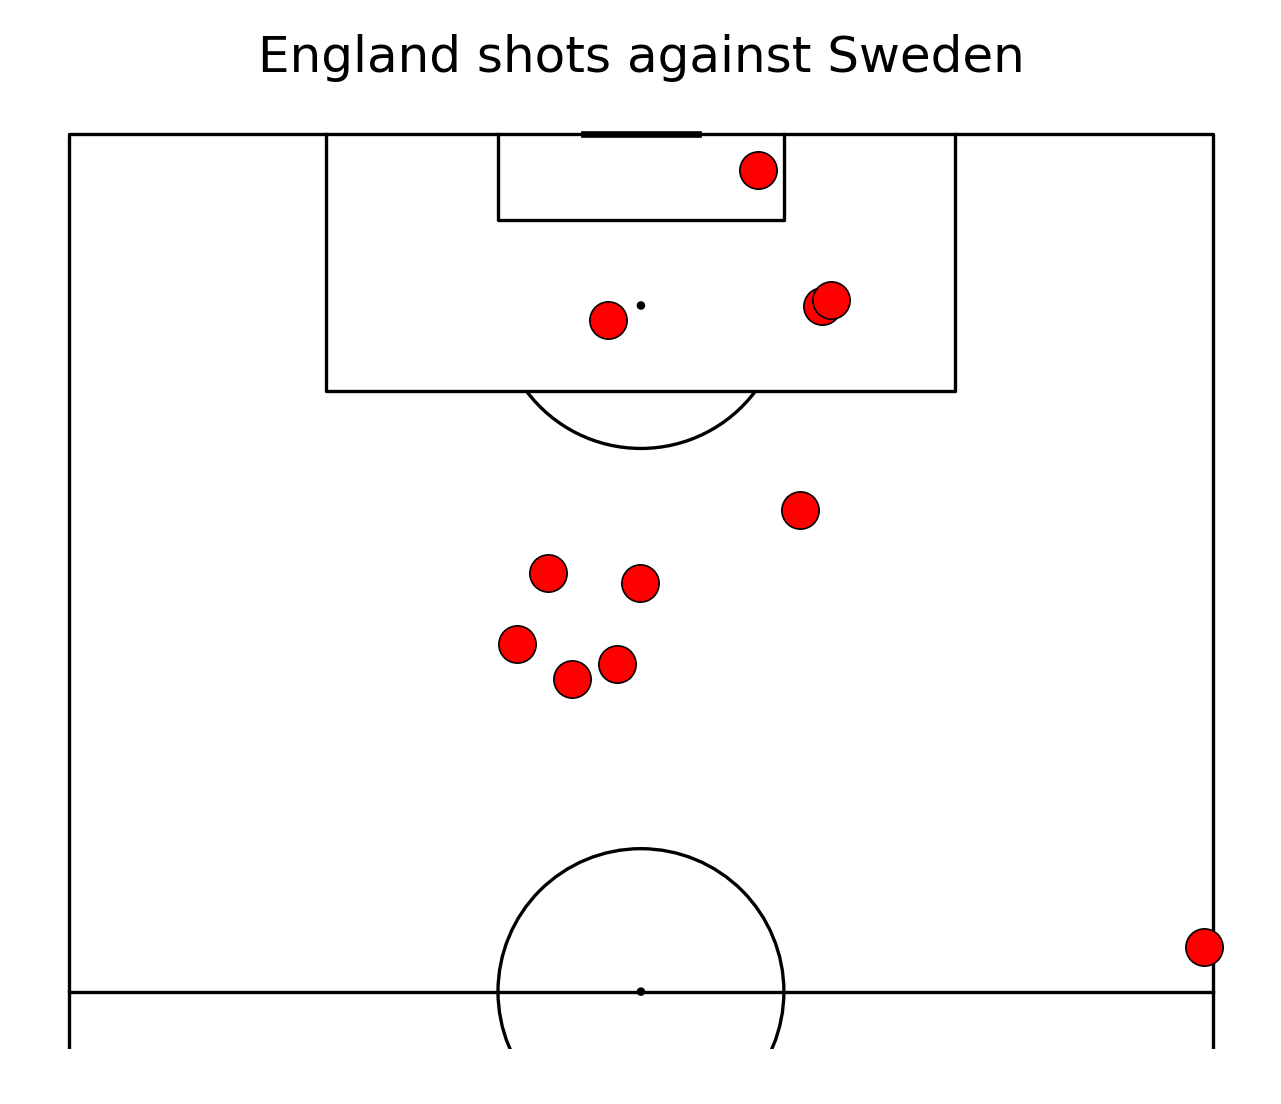

In [ ]:
pitch = VerticalPitch(line_color='black', half = True)
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#plotting all shots
pitch.scatter(df_england.x, df_england.y, alpha = 1, s = 500, color = "red", ax=ax['pitch'], edgecolors="black")
fig.suptitle("England shots against Sweden", fontsize = 30)
plt.show()

# Plotting passes

In [ ]:
passes = df.loc[df['type_name'] == 'Pass'].loc[df['sub_type_name'] != 'Throw-in'].set_index('id')

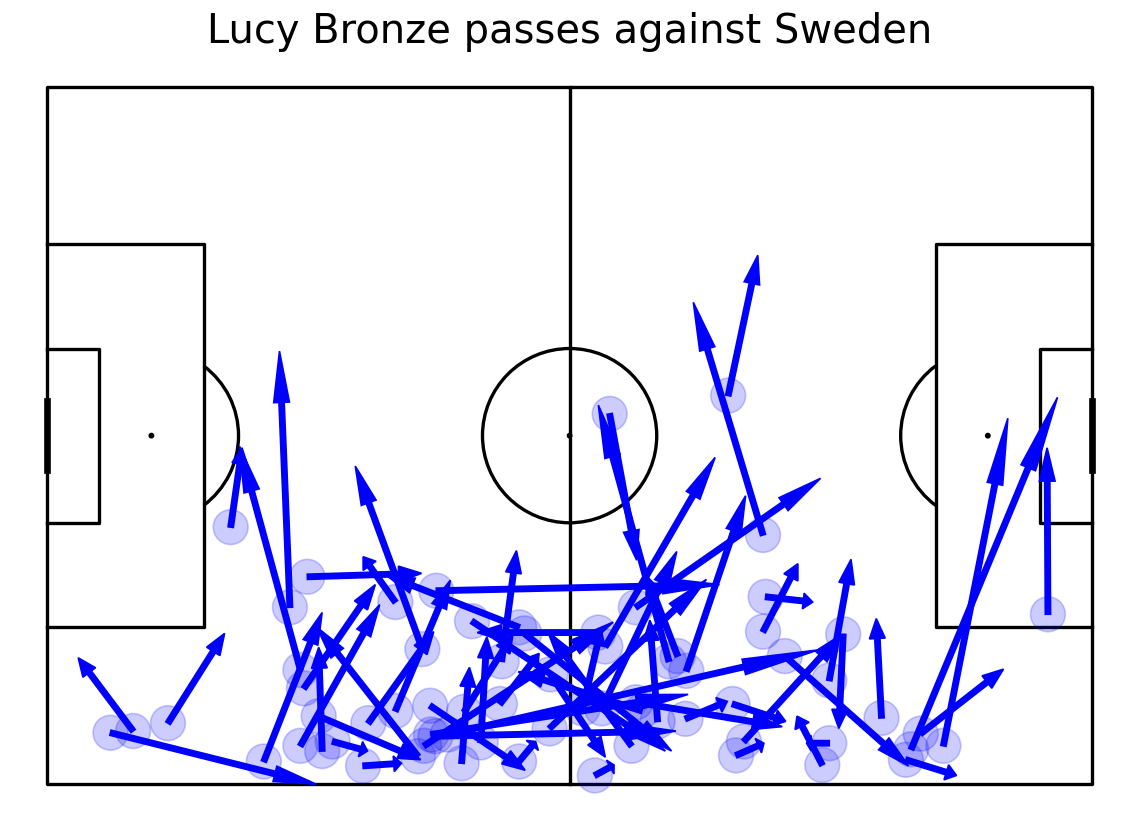

In [ ]:
#drawing pitch
pitch = Pitch(line_color = "black")
fig, ax = pitch.draw(figsize=(10, 7))

for i,thepass in passes.iterrows():
    #if pass made by Lucy Bronze
    if thepass['player_name']=='Lucy Bronze':
        x=thepass['x']
        y=thepass['y']
        #plot circle
        passCircle=plt.Circle((x,y),2,color="blue")
        passCircle.set_alpha(.2)
        ax.add_patch(passCircle)
        dx=thepass['end_x']-x
        dy=thepass['end_y']-y
        #plot arrow
        passArrow=plt.Arrow(x,y,dx,dy,width=3,color="blue")
        ax.add_patch(passArrow)

ax.set_title("Lucy Bronze passes against Sweden", fontsize = 24)
fig.set_size_inches(10, 7)
plt.show()

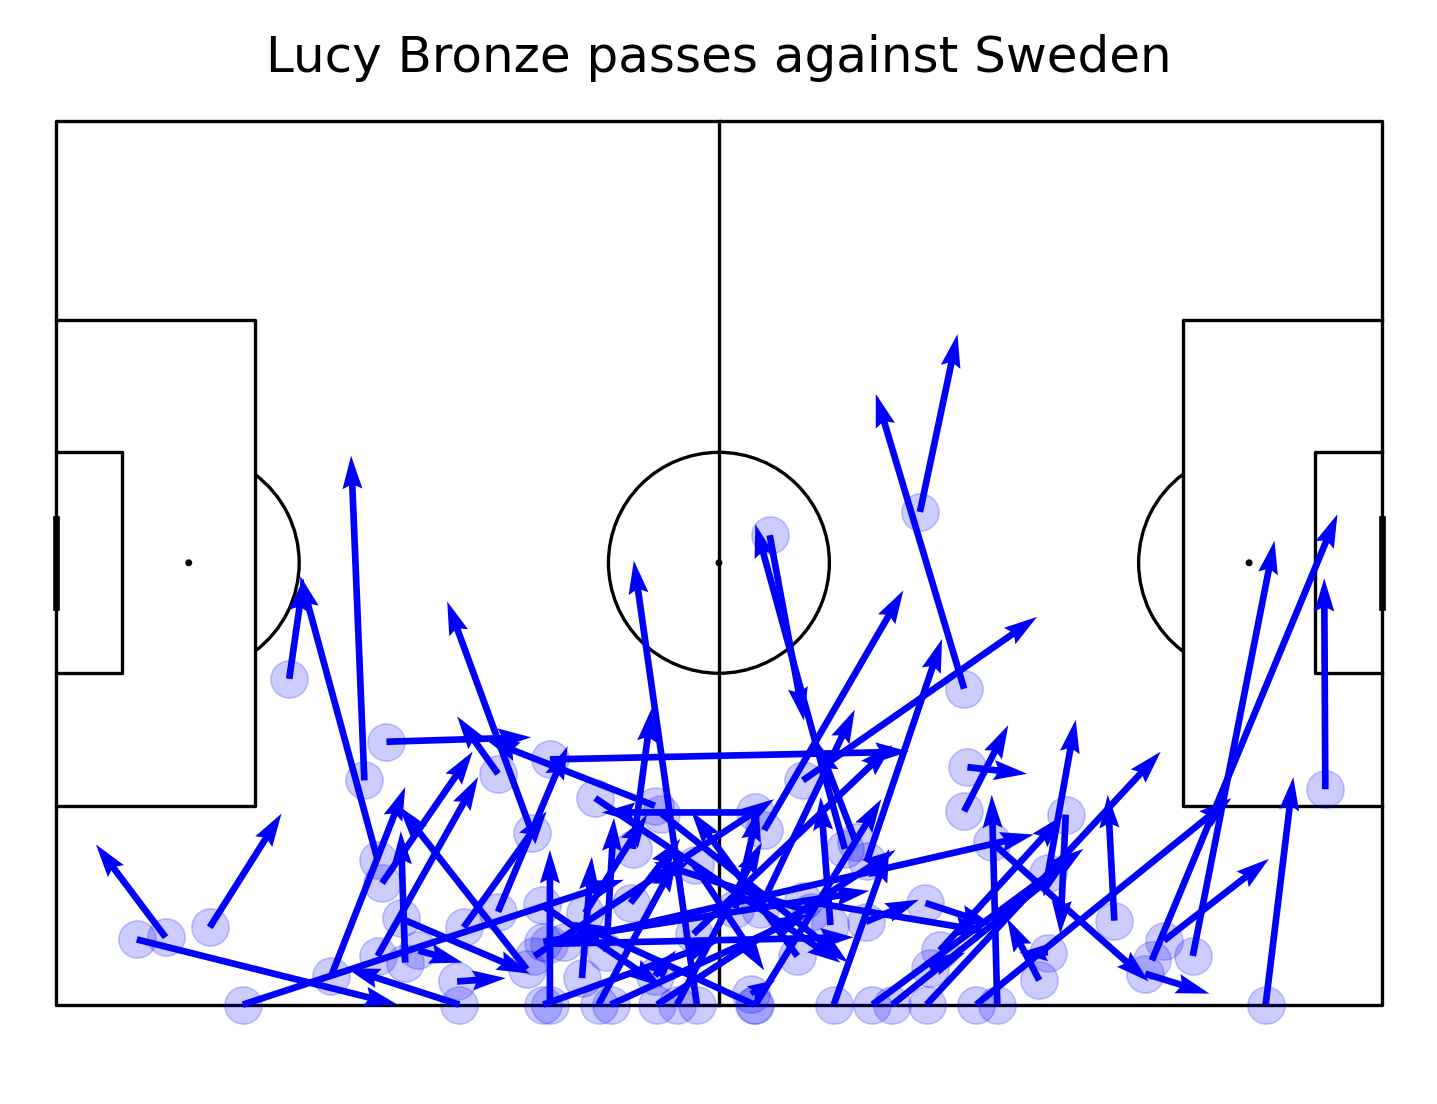

In [ ]:
mask_bronze = (df.type_name == 'Pass') & (df.player_name == "Lucy Bronze")
df_pass = df.loc[mask_bronze, ['x', 'y', 'end_x', 'end_y']]

pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.arrows(df_pass.x, df_pass.y,
            df_pass.end_x, df_pass.end_y, color = "blue", ax=ax['pitch'])
pitch.scatter(df_pass.x, df_pass.y, alpha = 0.2, s = 500, color = "blue", ax=ax['pitch'])
fig.suptitle("Lucy Bronze passes against Sweden", fontsize = 30)
plt.show()

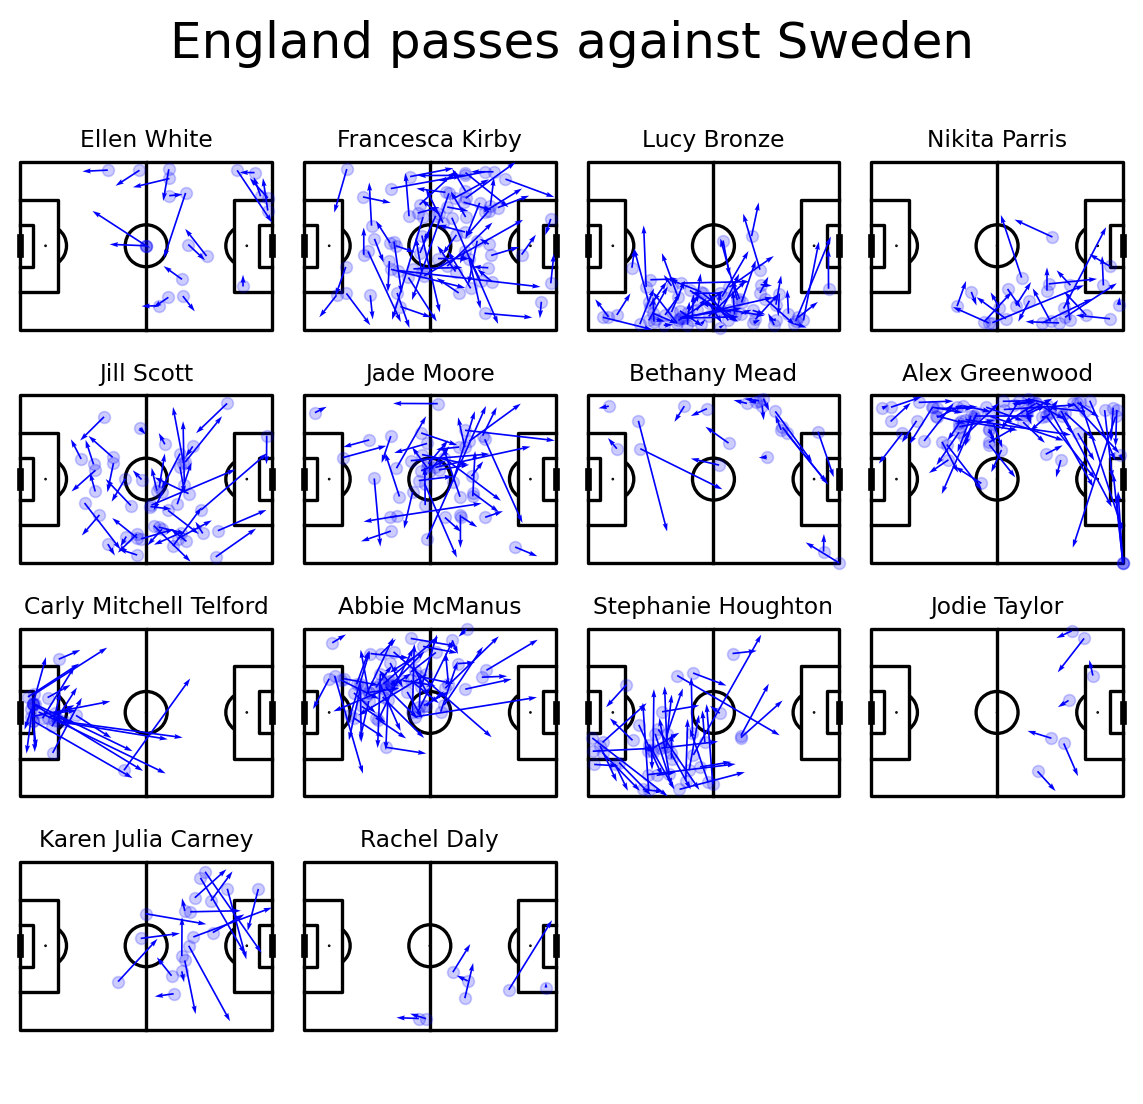

In [ ]:
#prepare the dataframe of passes by England that were no-throw ins
mask_england = (df.type_name == 'Pass') & (df.team_name == "England Women's") & (df.sub_type_name != "Throw-in")
df_passes = df.loc[mask_england, ['x', 'y', 'end_x', 'end_y', 'player_name']]
#get the list of all players who made a pass
names = df_passes['player_name'].unique()

#draw 4x4 pitches
pitch = Pitch(line_color='black', pad_top=20)
fig, axs = pitch.grid(ncols = 4, nrows = 4, grid_height=0.85, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0.04, endnote_space=0.01)

#for each player
for name, ax in zip(names, axs['pitch'].flat[:len(names)]):
    #put player name over the plot
    ax.text(60, -10, name,
            ha='center', va='center', fontsize=14)
    #take only passes by this player
    player_df = df_passes.loc[df_passes["player_name"] == name]
    #scatter
    pitch.scatter(player_df.x, player_df.y, alpha = 0.2, s = 50, color = "blue", ax=ax)
    #plot arrow
    pitch.arrows(player_df.x, player_df.y,
            player_df.end_x, player_df.end_y, color = "blue", ax=ax, width=1)

#We have more than enough pitches - remove them
for ax in axs['pitch'][-1, 16 - len(names):]:
    ax.remove()

#Another way to set title using mplsoccer
axs['title'].text(0.5, 0.5, 'England passes against Sweden', ha='center', va='center', fontsize=30)
plt.show()

# Passing Networks

In [ ]:
#check for index of first sub
sub = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "England Women's"].iloc[0]["index"]
#make df with successfull passes by England until the first substitution
mask_england = (df.type_name == 'Pass') & (df.team_name == "England Women's") & (df.index < sub) & (df.outcome_name.isnull()) & (df.sub_type_name != "Throw-in")
#taking necessary columns
df_pass = df.loc[mask_england, ['x', 'y', 'end_x', 'end_y', "player_name", "pass_recipient_name"]]
#adjusting that only the surname of a player is presented.
df_pass["player_name"] = df_pass["player_name"].apply(lambda x: str(x).split()[-1])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].apply(lambda x: str(x).split()[-1])

In [ ]:
scatter_df = pd.DataFrame()
for i, name in enumerate(df_pass["player_name"].unique()):
    passx = df_pass.loc[df_pass["player_name"] == name]["x"].to_numpy()
    recx = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_x"].to_numpy()
    passy = df_pass.loc[df_pass["player_name"] == name]["y"].to_numpy()
    recy = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_y"].to_numpy()
    scatter_df.at[i, "player_name"] = name
    #make sure that x and y location for each circle representing the player is the average of passes and receptions
    scatter_df.at[i, "x"] = np.mean(np.concatenate([passx, recx]))
    scatter_df.at[i, "y"] = np.mean(np.concatenate([passy, recy]))
    #calculate number of passes
    scatter_df.at[i, "no"] = df_pass.loc[df_pass["player_name"] == name].count().iloc[0]

#adjust the size of a circle so that the player who made more passes gets the largest circle
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max() * 1500)

In [ ]:
#counting passes between players
df_pass["pair_key"] = df_pass.apply(lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1)
lines_df = df_pass.groupby(["pair_key"]).x.count().reset_index()
lines_df.rename({'x':'pass_count'}, axis='columns', inplace=True)
#setting a treshold. You can try to investigate how it changes when you change it.
lines_df = lines_df[lines_df['pass_count']>2]

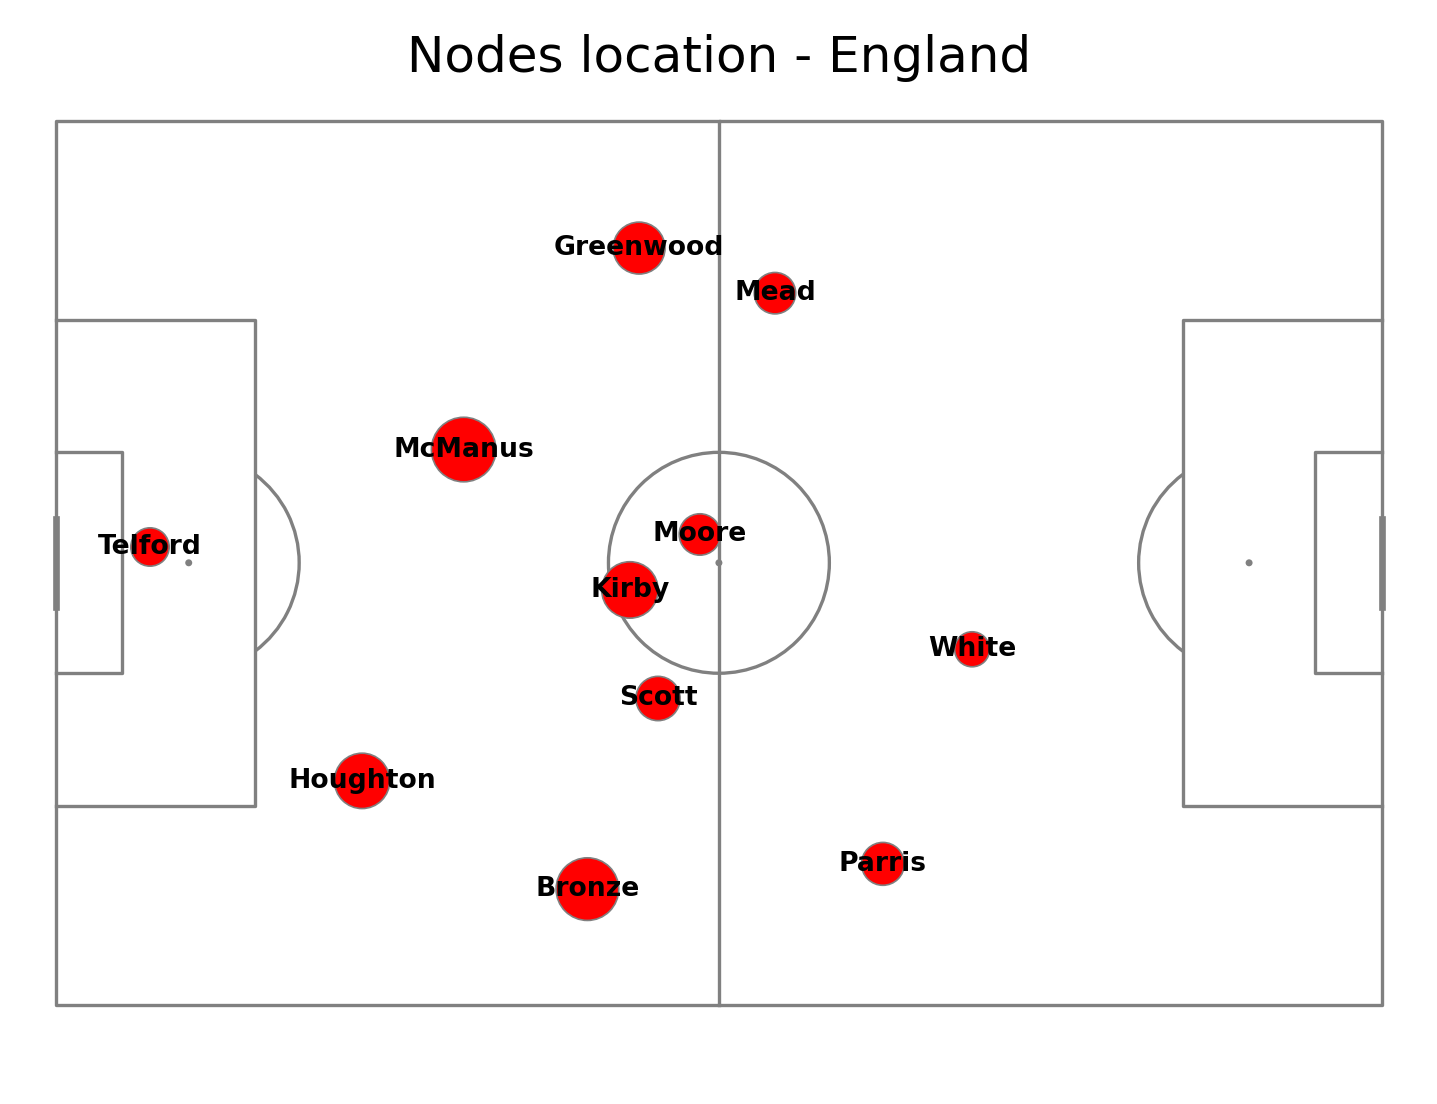

In [ ]:
#Drawing pitch
pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#Scatter the location on the pitch
pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)
#annotating player name
for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)

fig.suptitle("Nodes location - England", fontsize = 30)
plt.show()

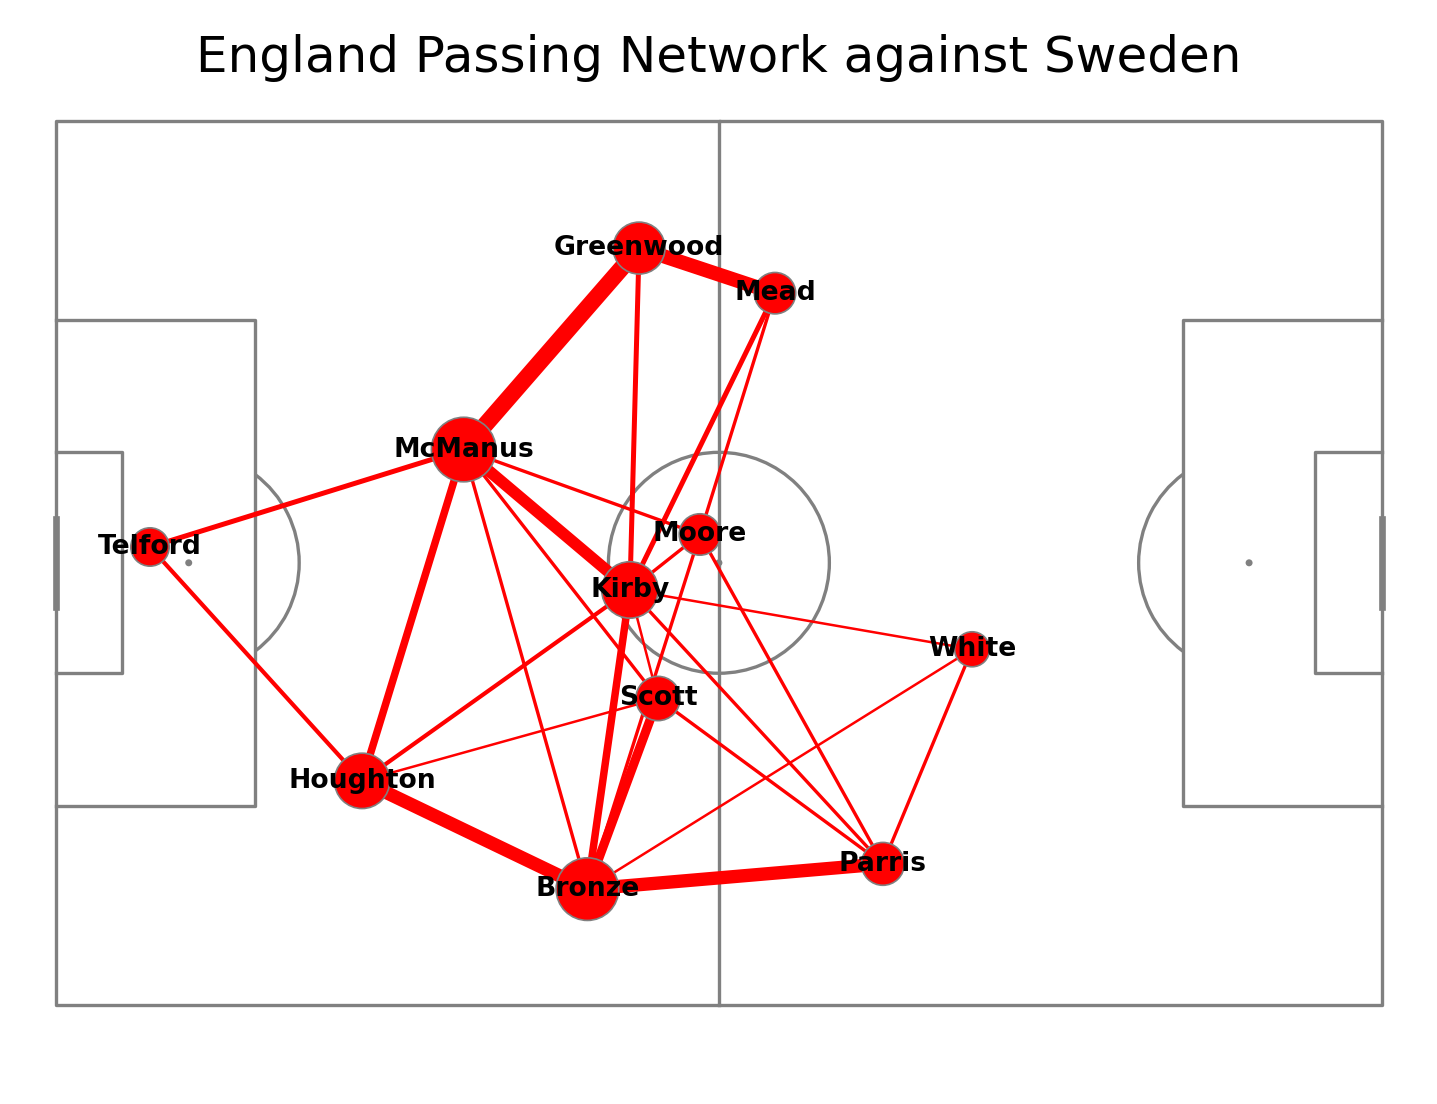

In [ ]:
#plot once again pitch and vertices
pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)
for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)

for i, row in lines_df.iterrows():
        player1 = row["pair_key"].split("_")[0]
        player2 = row['pair_key'].split("_")[1]
        #take the average location of players to plot a line between them
        player1_x = scatter_df.loc[scatter_df["player_name"] == player1]['x'].iloc[0]
        player1_y = scatter_df.loc[scatter_df["player_name"] == player1]['y'].iloc[0]
        player2_x = scatter_df.loc[scatter_df["player_name"] == player2]['x'].iloc[0]
        player2_y = scatter_df.loc[scatter_df["player_name"] == player2]['y'].iloc[0]
        num_passes = row["pass_count"]
        #adjust the line width so that the more passes, the wider the line
        line_width = (num_passes / lines_df['pass_count'].max() * 10)
        #plot lines on the pitch
        pitch.lines(player1_x, player1_y, player2_x, player2_y,
                        alpha=1, lw=line_width, zorder=2, color="red", ax = ax["pitch"])

fig.suptitle("England Passing Network against Sweden", fontsize = 30)
plt.show()

In [ ]:
#calculate number of successful passes by player
no_passes = df_pass.groupby(['player_name']).x.count().reset_index()
no_passes.rename({'x':'pass_count'}, axis='columns', inplace=True)
#find one who made most passes
max_no = no_passes["pass_count"].max()
#calculate the denominator - 10*the total sum of passes
denominator = 10*no_passes["pass_count"].sum()
#calculate the nominator
nominator = (max_no - no_passes["pass_count"]).sum()
#calculate the centralisation index
centralisation_index = nominator/denominator
print("Centralisation index is ", centralisation_index)

Centralisation index is  0.07


# Heat Map

In [ ]:
#open the data
parser = Sbopen()
df_match = parser.match(competition_id=72, season_id=30)
#selected team
team = "England Women's"
#get list of games by selected team, either home or away
match_ids = df_match.loc[(df_match["home_team_name"] == team) | (df_match["away_team_name"] == team)]["match_id"].tolist()
#calculate number of games
no_games = len(match_ids)

In [ ]:
#Open event data for all matches and concatenate them
df_all_events = pd.DataFrame()
for match_id in match_ids:
    df_events = parser.event(match_id)[0]
    df_all_events = pd.concat([df_all_events, df_events])


#Identify danger passes
#Add time in seconds column
df_all_events["time_seconds"] = df_all_events["minute"]*60 + df_all_events["second"]
#Take out the shots
df_shots = df_all_events[(df_all_events['type_name'] == 'Shot')]
#Only keep the necessary columns about shots
df_shots = df_shots[['match_id', 'possession', 'time_seconds']]
#Take out the open play successful passes from the possession team
df_passes = df_all_events[(df_all_events['type_name'] == 'Pass')
                          & (df_all_events['outcome_name'].isnull())
                          & (df_all_events['possession_team_id'] == df_all_events['team_id'])
                          & (~df_all_events.sub_type_name.isin(['Throw-in','Corner','Free Kick', 'Kick Off', 'Goal Kick']))
                          ]
# Merge shots and passes on possession and match_id
# Use a inner join to keep only passes that have a matching shot in the same possession
df_merged = df_shots.merge(df_passes, on=['possession', 'match_id'], how='inner',suffixes=('_shot',''))
# Calculate time difference between pass and shot
df_merged['time_diff'] = df_merged['time_seconds_shot'] - df_merged['time_seconds']
# Keep only passes that occurred within 15 seconds before the shot
df_danger_passes = df_merged[df_merged['time_diff'].between(0,15)]
# Some possessions may have multiple shots, keep only the shot with the smallest time_diff to each pass
first_shot = df_danger_passes.groupby('id')['time_diff'].idxmin()
df_danger_passes = df_danger_passes.loc[first_shot].reset_index(drop=True)
# Filter for our team
df_danger_passes = df_danger_passes[df_danger_passes['team_name'] == team]
# Only keep necessary columns
danger_passes = df_danger_passes[['x', 'y', 'end_x', 'end_y', 'minute','second','player_name']]

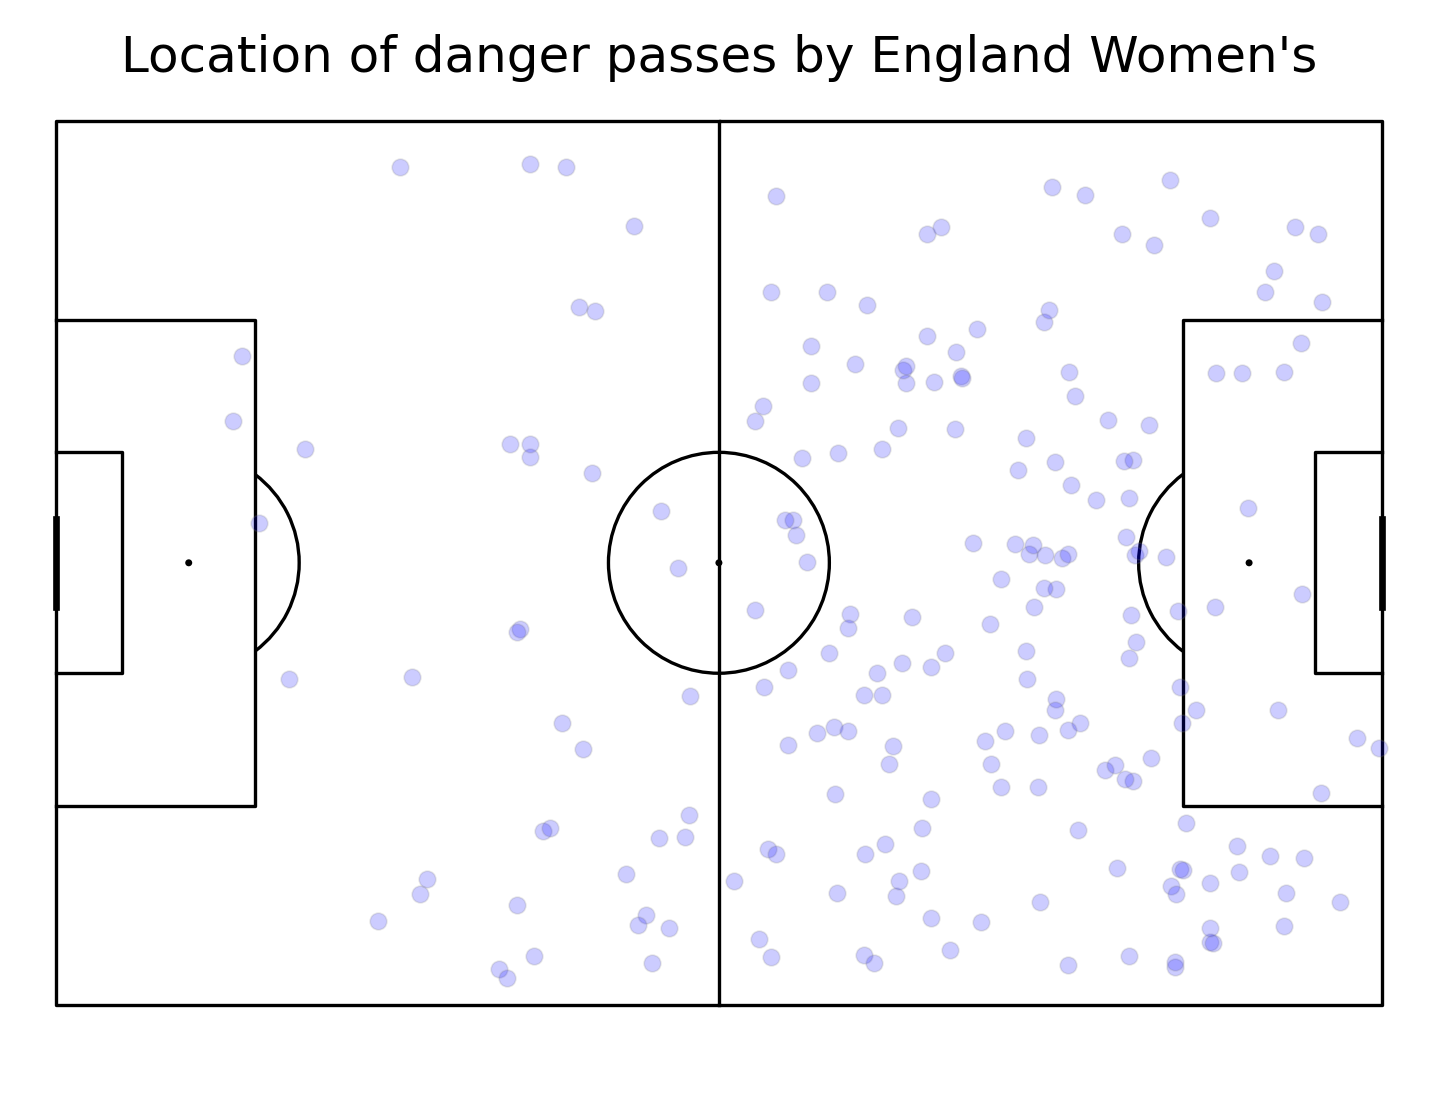

In [ ]:
#plot pitch
pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#scatter the location on the pitch
pitch.scatter(danger_passes.x, danger_passes.y, s=100, color='blue', edgecolors='grey', linewidth=1, alpha=0.2, ax=ax["pitch"])
#uncomment it to plot arrows
#pitch.arrows(danger_passes.x, danger_passes.y, danger_passes.end_x, danger_passes.end_y, color = "blue", ax=ax['pitch'])
#add title
fig.suptitle('Location of danger passes by ' + team, fontsize = 30)
plt.show()

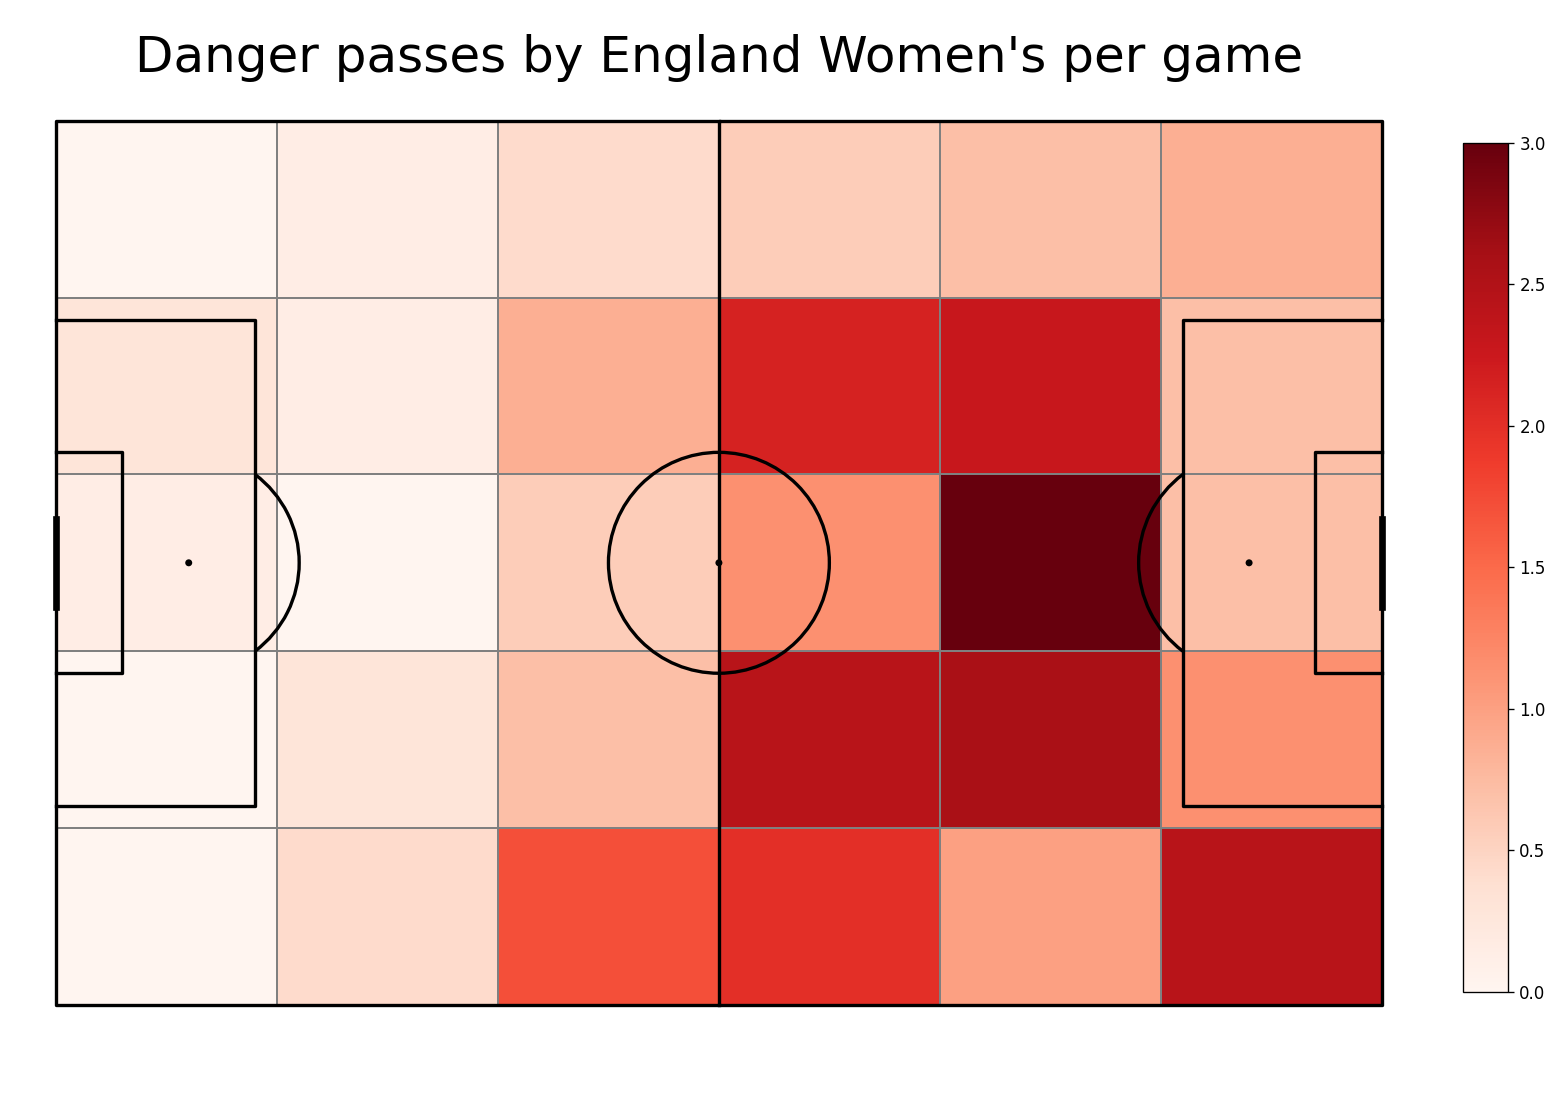

In [ ]:
pitch = Pitch(line_zorder=2, line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#get the 2D histogram
bin_statistic = pitch.bin_statistic(danger_passes.x, danger_passes.y, statistic='count', bins=(6, 5), normalize=False)
#normalize by number of games
bin_statistic["statistic"] = bin_statistic["statistic"]/no_games
#make a heatmap
pcm  = pitch.heatmap(bin_statistic, cmap='Reds', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Danger passes by ' + team + " per game", fontsize = 30)
plt.show()

/tmp/ipython-input-572644275.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  danger_passes["player_name"] = danger_passes["player_name"].apply(lambda x: str(x).split()[-1])


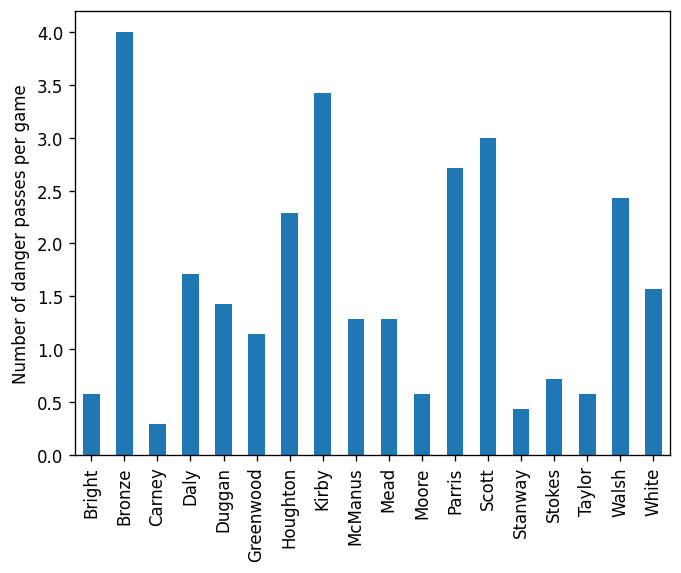

In [ ]:
#keep only surnames
danger_passes["player_name"] = danger_passes["player_name"].apply(lambda x: str(x).split()[-1])
#count passes by player and normalize them
pass_count = danger_passes.groupby(["player_name"]).x.count()/no_games
#make a histogram
ax = pass_count.plot.bar(pass_count)
#make legend
ax.set_xlabel("")
ax.set_ylabel("Number of danger passes per game")
plt.show()